## Evaluación en test 

In [1]:
import random
import torch
import matplotlib.pyplot as plt
import supervision as sv
import numpy as np
import re
import cv2
import os 

from pathlib import Path
from ultralytics import YOLO
from tqdm import tqdm
from collections import defaultdict
from configparser import ConfigParser


In [2]:
project_root = Path.cwd().parent.parent.parent
os.chdir(project_root)
print("Working directory changed to:", Path.cwd())

Working directory changed to: /home/valen/tp-furbo


In [3]:
BASELINE_MODEL_PATH = Path("runs/detect/train3/weights/best.pt")
BALL_MODEL_PATH = Path("runs/ball/weights/best.pt")

TEST_IMAGES_DIR = Path("data/tracking/raw/test")


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

baseline_model = YOLO(str(BASELINE_MODEL_PATH))
baseline_model.to(device)
print("Loaded model from:", BASELINE_MODEL_PATH)

names = baseline_model.names  
print("Classes:", names)

ball_model = YOLO(str(BALL_MODEL_PATH))
ball_model.to(device)
print("Loaded ball model from:", BALL_MODEL_PATH)
names_ball = ball_model.names
print("Ball model classes:", names_ball)

Using device: cuda
Loaded model from: runs/detect/train3/weights/best.pt
Classes: {0: 'player', 1: 'referee', 2: 'ball'}
Loaded ball model from: runs/ball/weights/best.pt
Ball model classes: {0: 'ball'}


In [5]:
BASELINE_BALL_CLASS_ID = 2


## Funciones para la inferencia

Inferir en modelo baseline es asi

In [6]:

def infer_frame(
    frame_or_path,
    baseline_conf: float = 0.35,
) -> sv.Detections:
    """
    Run baseline model and return sv.Detections.
    Acepta:
      - frame_or_path: np.ndarray (imagen ya cargada) 
      - o bien ruta (str / Path) al archivo de imagen.
    """
    if isinstance(frame_or_path, (str, Path)):
        baseline_result = baseline_model(str(frame_or_path), conf=baseline_conf, verbose=False)[0]
    else:
        # asumimos np.ndarray
        baseline_result = baseline_model(frame_or_path, conf=baseline_conf, verbose=False)[0]

    det_baseline = sv.Detections.from_ultralytics(baseline_result)
    return det_baseline


En el de la pelota, pero sin slicing.

In [7]:
def infer_ball(
    frame: np.ndarray,
    conf: float = 0.1,
) -> sv.Detections:
    
    ball_result = ball_model(frame, conf=conf, verbose=False)[0]
    det_ball = sv.Detections.from_ultralytics(ball_result)
    if len(det_ball) > 0:
        det_ball.class_id = np.full_like(det_ball.class_id, 0)
    return det_ball
    

En el de la pelota, pero con slicing (fue entrenado para esto).

In [8]:
def infer_ball_sliced(frame: np.ndarray, conf: float = 0.1) -> sv.Detections:
    """Run ball model with slicing over the whole frame."""
    h, w, _ = frame.shape

    def callback(patch: np.ndarray) -> sv.Detections:
        results = ball_model(patch, conf=conf, verbose=False)[0]
        det = sv.Detections.from_ultralytics(results)
        if len(det) > 0:
            det.class_id = np.full_like(det.class_id, 0)
        return det

    slicer = sv.InferenceSlicer(
        callback=callback,
        overlap_filter=sv.OverlapFilter.NON_MAX_SUPPRESSION,
        slice_wh=(w // 2 + 100, h // 2 + 100),
        overlap_wh=(100, 100),
        iou_threshold=0.1,
    )

    detections = slicer(frame)
    return detections

# Idea principal

Iterar por algunas de las carpetas (en total son 84 clips en test, y entrené con 110), calcular las detecciones del YOLO baseline (incluyendo la pelota), el YOLO sólo de la pelota. También incluir la clasificación de equipos porque el GT marca cada equipo.

In [9]:
clip_dir_pat = re.compile(r"SNMOT-(\d+)$")

clip_to_frames: dict[int, int] = {}
clip_id_to_dir: dict[int, Path] = {}

for d in TEST_IMAGES_DIR.iterdir():
    if not d.is_dir():
        continue

    m = clip_dir_pat.match(d.name)
    if not m:
        continue

    clip_id = int(m.group(1))
    img_dir = d / "img1"
    if not img_dir.is_dir():
        continue

    frame_paths = sorted(img_dir.glob("*.jpg"))
    if not frame_paths:
        continue

    clip_to_frames[clip_id] = len(frame_paths)
    clip_id_to_dir[clip_id] = d

clip_ids = sorted(clip_to_frames.keys())
print(f"{len(clip_ids)} clips in {TEST_IMAGES_DIR}")

N_CLIPS = 5
sampled_clip_ids = random.sample(clip_ids, k=min(N_CLIPS, len(clip_ids)))

print("Sampled clip IDs:", sampled_clip_ids)

49 clips in data/tracking/raw/test
Sampled clip IDs: [126, 123, 121, 193, 120]


In [10]:
from src.evaluation.tracking.utils import load_clip_frames_and_gt

frames_by_clip: dict[int, dict[int, Path]] = {}
gt_by_clip: dict[int, dict[int, sv.Detections]] = {}
tracklet_meta_by_clip: dict[int, dict[int, dict]] = {}
name_to_class_id = {v: k for k, v in names.items()}

for cid in sampled_clip_ids:
    f_idx, gt_idx, meta = load_clip_frames_and_gt(cid, clip_id_to_dir, name_to_class_id)
    frames_by_clip[cid] = f_idx
    gt_by_clip[cid] = gt_idx
    tracklet_meta_by_clip[cid] = meta

print(f"Cargados {len(frames_by_clip)} clips con frames e información de GT.")

# Ejemplo rápido: mostrar cuántos objetos hay en el primer frame del primer clip
example_clip = sampled_clip_ids[0]
example_frame = min(frames_by_clip[example_clip].keys())
print("Ejemplo:")
print("  Clip:", example_clip)
print("  Frame:", example_frame)
print("  Imagen:", frames_by_clip[example_clip][example_frame])
print("  Num GT boxes:", len(gt_by_clip[example_clip][example_frame]))
print("  GT class_ids:", gt_by_clip[example_clip][example_frame].class_id)
print("  GT team_ab:", gt_by_clip[example_clip][example_frame].data.get("team_ab"))

Cargados 5 clips con frames e información de GT.
Ejemplo:
  Clip: 126
  Frame: 1
  Imagen: data/tracking/raw/test/SNMOT-126/img1/000001.jpg
  Num GT boxes: 11
  GT class_ids: [0 0 0 0 0 0 0 0 0 1 2]
  GT team_ab: ['team_B' 'team_A' 'team_A' 'team_B' 'team_B' 'team_B' 'team_A' 'team_A' 'team_B' None None]


In [11]:
import cv2
import numpy as np
from collections import defaultdict

# IDs de clase (del modelo baseline)
PLAYER_CLASS_ID = name_to_class_id["player"]
REFEREE_CLASS_ID = name_to_class_id["referee"]
BALL_CLASS_ID = BASELINE_BALL_CLASS_ID  # normalmente 2

IOU_THRESH = 0.5


def compute_iou(box1: np.ndarray, box2: np.ndarray) -> float:
    """IoU entre dos cajas [x1, y1, x2, y2]."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter_area = inter_w * inter_h

    if inter_area <= 0:
        return 0.0

    area1 = max(0.0, (box1[2] - box1[0])) * max(0.0, (box1[3] - box1[1]))
    area2 = max(0.0, (box2[2] - box2[0])) * max(0.0, (box2[3] - box2[1]))
    union = area1 + area2 - inter_area

    if union <= 0:
        return 0.0

    return inter_area / union


def match_class_boxes(
    pred_boxes: np.ndarray,
    gt_boxes: np.ndarray,
    iou_thresh: float = 0.5,
) -> tuple[int, int, int, np.ndarray]:
    """
    Matching greedy 1-a-1 para una sola clase.
    Devuelve:
      tp, fp, fn, is_tp_pred  (is_tp_pred es un bool array de largo num_pred)
    """
    num_pred = len(pred_boxes)
    num_gt = len(gt_boxes)

    if num_pred == 0 and num_gt == 0:
        return 0, 0, 0, np.zeros((0,), dtype=bool)

    matched_gt = set()
    tp = 0
    fp = 0
    is_tp = np.zeros((num_pred,), dtype=bool)

    for i in range(num_pred):
        best_iou = 0.0
        best_j = -1
        for j in range(num_gt):
            if j in matched_gt:
                continue
            iou = compute_iou(pred_boxes[i], gt_boxes[j])
            if iou > best_iou:
                best_iou = iou
                best_j = j

        if best_iou >= iou_thresh and best_j >= 0:
            tp += 1
            matched_gt.add(best_j)
            is_tp[i] = True
        else:
            fp += 1

    fn = num_gt - len(matched_gt)
    return tp, fp, fn, is_tp


def summarize_stats(name: str, stats: dict):
    tp = stats["tp"]
    fp = stats["fp"]
    fn = stats["fn"]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    if precision + recall > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0.0

    print(f"{name}:")
    print(f"  TP = {tp}, FP = {fp}, FN = {fn}")
    print(f"  Precision = {precision:.3f}")
    print(f"  Recall    = {recall:.3f}")
    print(f"  F1        = {f1:.3f}")
    print()


# ---------------------------------------------------------------------
# Acumuladores GLOBAL detection stats (player + referee, baseline)
# ---------------------------------------------------------------------
stats = {
    "all": {"tp": 0, "fp": 0, "fn": 0},
    PLAYER_CLASS_ID: {"tp": 0, "fp": 0, "fn": 0},
    REFEREE_CLASS_ID: {"tp": 0, "fp": 0, "fn": 0},
}

# Datos para curvas PR / Precision-Confidence por clase (baseline, player/referee)
# pr_data_players_ref[class_id]["conf"] -> lista de confidences
# pr_data_players_ref[class_id]["is_tp"] -> lista de bools del mismo largo
pr_data_players_ref = {
    PLAYER_CLASS_ID: {"conf": [], "is_tp": []},
    REFEREE_CLASS_ID: {"conf": [], "is_tp": []},
}

# Datos para matriz de confusión (baseline, sólo player/referee)
# y_true_conf/y_pred_conf: listas de class_id GT/pred de cada emparejamiento IoU>thr
confusion_true = []
confusion_pred = []


def match_for_confusion(
    pred_boxes: np.ndarray,
    pred_cls: np.ndarray,
    gt_boxes: np.ndarray,
    gt_cls: np.ndarray,
    iou_thresh: float = 0.5,
):
    """
    Matching greedy multi-clase para matriz de confusión.
    Devuelve lista de pares (pred_idx, gt_idx).
    """
    num_pred = len(pred_boxes)
    num_gt = len(gt_boxes)

    if num_pred == 0 or num_gt == 0:
        return []

    # Matriz de IoU
    iou_mat = np.zeros((num_pred, num_gt), dtype=float)
    for i in range(num_pred):
        for j in range(num_gt):
            iou_mat[i, j] = compute_iou(pred_boxes[i], gt_boxes[j])

    used_pred = set()
    used_gt = set()
    matches = []

    while True:
        # buscamos el máximo IoU aún disponible
        best_iou = 0.0
        best_i = -1
        best_j = -1
        for i in range(num_pred):
            if i in used_pred:
                continue
            for j in range(num_gt):
                if j in used_gt:
                    continue
                if iou_mat[i, j] > best_iou:
                    best_iou = iou_mat[i, j]
                    best_i = i
                    best_j = j
        if best_iou < iou_thresh or best_i < 0 or best_j < 0:
            break

        matches.append((best_i, best_j))
        used_pred.add(best_i)
        used_gt.add(best_j)

    return matches


# ---------------------------------------------------------------------
# Acumuladores para pelota: 3 modelos
# ---------------------------------------------------------------------
ball_models = ["baseline", "ball", "ball_sliced"]

ball_stats = {
    m: {"tp": 0, "fp": 0, "fn": 0}
    for m in ball_models
}

# ball_pr_data[model]["conf"] / ["is_tp"]
ball_pr_data = {
    m: {"conf": [], "is_tp": []}
    for m in ball_models
}

num_frames_evaluated_pr = 0  # frames con algo de player/referee
num_frames_ball = {m: 0 for m in ball_models}

# Podés limitar frames por clip si querés acelerar
MAX_FRAMES_PER_CLIP = None  # o por ejemplo 100

for cid in sampled_clip_ids:
    frames_dict = frames_by_clip[cid]
    gt_dict = gt_by_clip[cid]

    frame_indices = sorted(frames_dict.keys())
    if MAX_FRAMES_PER_CLIP is not None:
        frame_indices = frame_indices[:MAX_FRAMES_PER_CLIP]

    for frame_idx in frame_indices:
        img_path = frames_dict[frame_idx]
        gt_det = gt_dict[frame_idx]

        # -------------------------
        # GT filtrado por tipos
        # -------------------------
        if len(gt_det) > 0:
            gt_mask_pr = np.isin(gt_det.class_id, [PLAYER_CLASS_ID, REFEREE_CLASS_ID])
            gt_det_pr = gt_det[gt_mask_pr]

            gt_mask_ball = (gt_det.class_id == BALL_CLASS_ID)
            gt_det_ball = gt_det[gt_mask_ball]
        else:
            gt_det_pr = gt_det
            gt_det_ball = gt_det

        # -------------------------------------------------
        # BASELINE: inferencia sobre ruta (todas las clases)
        # -------------------------------------------------
        pred_det_all = infer_frame(img_path, baseline_conf=0.01)

        # --------- PLAYER + REFEREE (baseline) -----------
        if len(gt_det_pr) > 0 or len(pred_det_all) > 0:
            # Filtramos predicciones player/referee
            if len(pred_det_all) > 0:
                pred_mask_pr = np.isin(
                    pred_det_all.class_id, [PLAYER_CLASS_ID, REFEREE_CLASS_ID]
                )
                pred_det_pr = pred_det_all[pred_mask_pr]
            else:
                pred_det_pr = pred_det_all

            if len(gt_det_pr) > 0 or len(pred_det_pr) > 0:
                num_frames_evaluated_pr += 1

                # a) stats por clase + PR data
                for cls_id in [PLAYER_CLASS_ID, REFEREE_CLASS_ID]:
                    gt_cls_mask = (gt_det_pr.class_id == cls_id)
                    pred_cls_mask = (pred_det_pr.class_id == cls_id)

                    gt_boxes = gt_det_pr.xyxy[gt_cls_mask]
                    pred_boxes = pred_det_pr.xyxy[pred_cls_mask]

                    if len(pred_boxes) > 0:
                        conf = pred_det_pr.confidence[pred_cls_mask]
                    else:
                        conf = np.empty((0,), dtype=float)

                    tp, fp, fn, is_tp = match_class_boxes(
                        pred_boxes, gt_boxes, IOU_THRESH
                    )

                    stats[cls_id]["tp"] += tp
                    stats[cls_id]["fp"] += fp
                    stats[cls_id]["fn"] += fn

                    stats["all"]["tp"] += tp
                    stats["all"]["fp"] += fp
                    stats["all"]["fn"] += fn

                    pr_data_players_ref[cls_id]["conf"].extend(conf.tolist())
                    pr_data_players_ref[cls_id]["is_tp"].extend(is_tp.tolist())

                # b) datos para matriz de confusión (match multi-clase)
                if len(pred_det_pr) > 0 and len(gt_det_pr) > 0:
                    matches = match_for_confusion(
                        pred_det_pr.xyxy,
                        pred_det_pr.class_id,
                        gt_det_pr.xyxy,
                        gt_det_pr.class_id,
                        IOU_THRESH,
                    )
                    for p_idx, g_idx in matches:
                        confusion_true.append(int(gt_det_pr.class_id[g_idx]))
                        confusion_pred.append(int(pred_det_pr.class_id[p_idx]))

        # -------------------------
        # PELOTA: 3 modelos
        # -------------------------
        # GT de pelota
        gt_boxes_ball = gt_det_ball.xyxy if len(gt_det_ball) > 0 else np.empty((0, 4))

        # 1) baseline (clase BALL_CLASS_ID)
        if len(pred_det_all) > 0:
            pred_mask_ball_base = (pred_det_all.class_id == BALL_CLASS_ID)
            pred_det_ball_base = pred_det_all[pred_mask_ball_base]
        else:
            pred_det_ball_base = pred_det_all

        if len(gt_boxes_ball) > 0 or len(pred_det_ball_base) > 0:
            num_frames_ball["baseline"] += 1
            pred_boxes = pred_det_ball_base.xyxy
            conf = (
                pred_det_ball_base.confidence
                if len(pred_det_ball_base) > 0
                else np.empty((0,), dtype=float)
            )
            tp, fp, fn, is_tp = match_class_boxes(
                pred_boxes, gt_boxes_ball, IOU_THRESH
            )
            ball_stats["baseline"]["tp"] += tp
            ball_stats["baseline"]["fp"] += fp
            ball_stats["baseline"]["fn"] += fn
            ball_pr_data["baseline"]["conf"].extend(conf.tolist())
            ball_pr_data["baseline"]["is_tp"].extend(is_tp.tolist())

        # 2) ball model (sin slicing)
        det_ball = infer_ball(img_path, conf=0.01)
        if len(gt_boxes_ball) > 0 or len(det_ball) > 0:
            num_frames_ball["ball"] += 1
            pred_boxes = det_ball.xyxy
            conf = (
                det_ball.confidence
                if len(det_ball) > 0
                else np.empty((0,), dtype=float)
            )
            tp, fp, fn, is_tp = match_class_boxes(
                pred_boxes, gt_boxes_ball, IOU_THRESH
            )
            ball_stats["ball"]["tp"] += tp
            ball_stats["ball"]["fp"] += fp
            ball_stats["ball"]["fn"] += fn
            ball_pr_data["ball"]["conf"].extend(conf.tolist())
            ball_pr_data["ball"]["is_tp"].extend(is_tp.tolist())

        # 3) ball_sliced (necesita frame en memoria)
        frame = cv2.imread(str(img_path))
        if frame is not None:
            det_ball_sliced = infer_ball_sliced(frame, conf=0.01)
        else:
            det_ball_sliced = sv.Detections(
                xyxy=np.empty((0, 4), dtype=float),
                class_id=np.empty((0,), dtype=int),
            )

        if len(gt_boxes_ball) > 0 or len(det_ball_sliced) > 0:
            num_frames_ball["ball_sliced"] += 1
            pred_boxes = det_ball_sliced.xyxy
            conf = (
                det_ball_sliced.confidence
                if len(det_ball_sliced) > 0
                else np.empty((0,), dtype=float)
            )
            tp, fp, fn, is_tp = match_class_boxes(
                pred_boxes, gt_boxes_ball, IOU_THRESH
            )
            ball_stats["ball_sliced"]["tp"] += tp
            ball_stats["ball_sliced"]["fp"] += fp
            ball_stats["ball_sliced"]["fn"] += fn
            ball_pr_data["ball_sliced"]["conf"].extend(conf.tolist())
            ball_pr_data["ball_sliced"]["is_tp"].extend(is_tp.tolist())


print(
    f"Frames evaluados (player/ref) con algo de GT o pred: {num_frames_evaluated_pr}\n"
)
for m in ball_models:
    print(f"Frames evaluados para pelota ({m}): {num_frames_ball[m]}")
print()

# Resumen player + referee (baseline)
summarize_stats("GLOBAL (player + referee)", stats["all"])
summarize_stats(f"PLAYER (class_id={PLAYER_CLASS_ID})", stats[PLAYER_CLASS_ID])
summarize_stats(f"REFEREE (class_id={REFEREE_CLASS_ID})", stats[REFEREE_CLASS_ID])

# Resumen pelota (3 modelos)
for m in ball_models:
    summarize_stats(f"BALL - {m}", ball_stats[m])


Frames evaluados (player/ref) con algo de GT o pred: 3750

Frames evaluados para pelota (baseline): 3260
Frames evaluados para pelota (ball): 3263
Frames evaluados para pelota (ball_sliced): 3317

GLOBAL (player + referee):
  TP = 52130, FP = 29658, FN = 2955
  Precision = 0.637
  Recall    = 0.946
  F1        = 0.762

PLAYER (class_id=0):
  TP = 48477, FP = 26804, FN = 1999
  Precision = 0.644
  Recall    = 0.960
  F1        = 0.771

REFEREE (class_id=1):
  TP = 3653, FP = 2854, FN = 956
  Precision = 0.561
  Recall    = 0.793
  F1        = 0.657

BALL - baseline:
  TP = 1021, FP = 2275, FN = 2172
  Precision = 0.310
  Recall    = 0.320
  F1        = 0.315

BALL - ball:
  TP = 1755, FP = 6181, FN = 1438
  Precision = 0.221
  Recall    = 0.550
  F1        = 0.315

BALL - ball_sliced:
  TP = 1663, FP = 3152, FN = 1530
  Precision = 0.345
  Recall    = 0.521
  F1        = 0.415



In [13]:
from sklearn.metrics import precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt

def evaluate_detections(pred_by_clip, gt_by_clip, classes_eval, iou_thresh=0.5):
    all_confidences = []
    all_true = []
    all_pred_classes = []
    all_gt_classes = []

    tp_sum, fp_sum, fn_sum = 0, 0, 0

    for cid in sampled_clip_ids:
        frames_dict = pred_by_clip[cid]
        gt_dict = gt_by_clip[cid]

        for frame_idx, pred_det in frames_dict.items():
            gt_det = gt_dict[frame_idx]

            # Filtrar por clases relevantes
            pred_mask = np.isin(pred_det.class_id, classes_eval)
            gt_mask = np.isin(gt_det.class_id, classes_eval)
            pred_det = pred_det[pred_mask]
            gt_det = gt_det[gt_mask]

            # Clasificación (para matriz de confusión)
            all_pred_classes.extend(pred_det.class_id)
            all_gt_classes.extend(gt_det.class_id)

            # Curva PR
            all_confidences.extend(pred_det.confidence if "confidence" in pred_det.data else np.ones(len(pred_det)))
            all_true.extend([1 if len(gt_det) > 0 else 0] * len(pred_det))

            # IoU matching
            tp, fp, fn = match_class_boxes(pred_det.xyxy, gt_det.xyxy, iou_thresh)
            tp_sum += tp
            fp_sum += fp
            fn_sum += fn

    precision = tp_sum / (tp_sum + fp_sum + 1e-8)
    recall = tp_sum / (tp_sum + fn_sum + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    print(f"Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

    # Matriz de confusión
    cm = confusion_matrix(all_gt_classes, all_pred_classes, labels=classes_eval, normalize="true")
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(classes_eval)))
    ax.set_yticks(range(len(classes_eval)))
    ax.set_xticklabels([baseline_model.names[c] for c in classes_eval])
    ax.set_yticklabels([baseline_model.names[c] for c in classes_eval])
    plt.colorbar(im)
    plt.title("Normalized Confusion Matrix")
    plt.show()

    # Curva PR
    prec, rec, _ = precision_recall_curve(all_true, all_confidences)
    plt.plot(rec, prec, label="PR Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # Precision–Confidence
    sorted_idx = np.argsort(all_confidences)
    conf_sorted = np.array(all_confidences)[sorted_idx]
    prec_sorted = np.array(prec)[np.searchsorted(rec[::-1], rec[::-1])]
    plt.plot(conf_sorted, prec_sorted, label="Precision-Confidence Curve")
    plt.xlabel("Confidence")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()


In [23]:
import numpy as np
import matplotlib.pyplot as plt

def build_pr_curve(conf_list, is_tp_list, total_gt):
    """
    A partir de:
      - conf_list: lista de confidences de las predicciones
      - is_tp_list: lista booleana indicando si cada predicción es TP
      - total_gt: cantidad total de GT de esa clase (tp + fn)
    devuelve:
      recall, precision, conf_sorted
    listas ordenadas por confianza descendente.
    """
    conf = np.array(conf_list, dtype=float)
    is_tp = np.array(is_tp_list, dtype=bool)

    if len(conf) == 0 or total_gt == 0:
        return np.array([0.0]), np.array([0.0]), np.array([0.0])

    order = np.argsort(-conf)  # confianza descendente
    conf_sorted = conf[order]
    tp_sorted = is_tp[order].astype(int)

    tps_cum = np.cumsum(tp_sorted)
    fps_cum = np.cumsum(1 - tp_sorted)
    denom = tps_cum + fps_cum

    precision = np.where(denom > 0, tps_cum / denom, 0.0)
    recall = tps_cum / float(total_gt)

    return recall, precision, conf_sorted


def build_pr_curve_monotone(conf_list, is_tp_list, total_gt):
    """
    Devuelve (recall, precision, conf_sorted) con precisión 'monotone' (envolvente).
    """
    conf = np.asarray(conf_list, dtype=float)
    is_tp = np.asarray(is_tp_list, dtype=bool)

    if total_gt <= 0 or conf.size == 0:
        return np.array([0.0, 1.0]), np.array([1.0, 1.0]), np.array([0.0, 0.0])

    order = np.argsort(-conf)  # confianza descendente
    conf_sorted = conf[order]
    tp_sorted = is_tp[order].astype(int)

    tps_cum = np.cumsum(tp_sorted)
    fps_cum = np.cumsum(1 - tp_sorted)
    denom = tps_cum + fps_cum
    precision = np.where(denom > 0, tps_cum / denom, 0.0)
    recall = tps_cum / float(total_gt)

    # Envolvente no creciente de la precisión (de derecha a izquierda)
    precision_envelope = precision.copy()
    for i in range(precision_envelope.size - 2, -1, -1):
        if precision_envelope[i] < precision_envelope[i + 1]:
            precision_envelope[i] = precision_envelope[i + 1]

    return recall, precision_envelope, conf_sorted


def plot_pr_curves(series, title):
    """
    series: lista de tuplas (recall, precision, label)
    """
    plt.figure(figsize=(8, 5))
    for rec, prec, label in series:
        # AP por trapecios sobre la curva ya “alisada”
        ap = np.trapz(prec, rec) if rec.size > 1 else 0.0
        plt.plot(rec, prec, label=f"{label} {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_pc_curves(series, title):
    """
    series: lista de tuplas (conf, precision, label)
    Usa la precisión al barrer umbral de confianza (mismo orden que la PR).
    """
    plt.figure(figsize=(8, 5))
    for conf, prec, label in series:
        plt.plot(conf, prec, label=label)
    plt.xlabel("Confidence")
    plt.ylabel("Precision")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


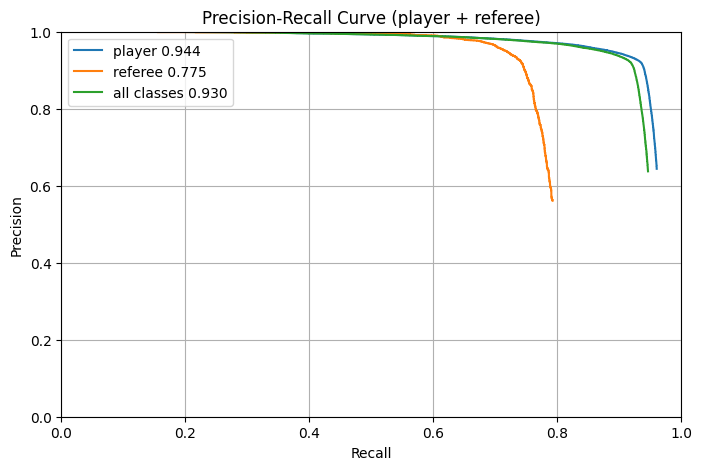

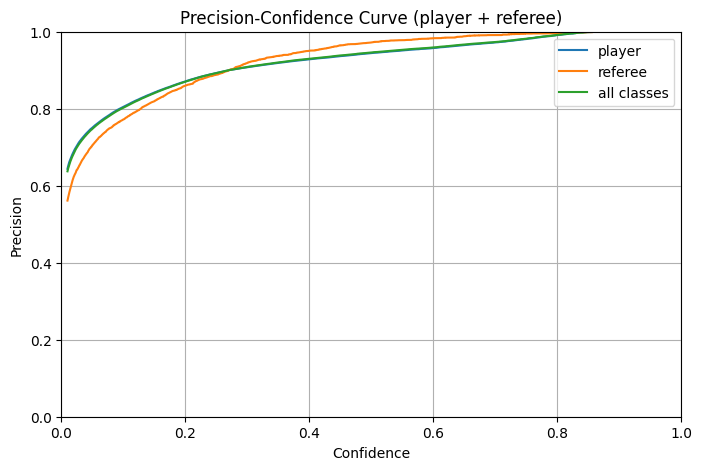

In [24]:
# --------- PLAYER + REFEREE (baseline) ---------
class_ids_pr = [PLAYER_CLASS_ID, REFEREE_CLASS_ID]

series_pr = []
series_pc = []

# Por clase
for cid in class_ids_pr:
    total_gt_c = stats[cid]["tp"] + stats[cid]["fn"]
    rec, prec, conf_sorted = build_pr_curve_monotone(
        pr_data_players_ref[cid]["conf"],
        pr_data_players_ref[cid]["is_tp"],
        total_gt_c,
    )
    series_pr.append((rec, prec, baseline_model.names[cid]))
    series_pc.append((conf_sorted, prec, baseline_model.names[cid]))

# “All classes” (player+referee juntos)
total_gt_all = stats["all"]["tp"] + stats["all"]["fn"]
all_conf = np.array(
    pr_data_players_ref[PLAYER_CLASS_ID]["conf"]
    + pr_data_players_ref[REFEREE_CLASS_ID]["conf"],
    dtype=float,
)
all_is_tp = np.array(
    pr_data_players_ref[PLAYER_CLASS_ID]["is_tp"]
    + pr_data_players_ref[REFEREE_CLASS_ID]["is_tp"],
    dtype=bool,
)

rec_all, prec_all, conf_all = build_pr_curve_monotone(all_conf, all_is_tp, total_gt_all)
series_pr.append((rec_all, prec_all, "all classes"))
series_pc.append((conf_all, prec_all, "all classes"))

# Plots
plot_pr_curves(series_pr, "Precision-Recall Curve (player + referee)")
plot_pc_curves(series_pc, "Precision-Confidence Curve (player + referee)")


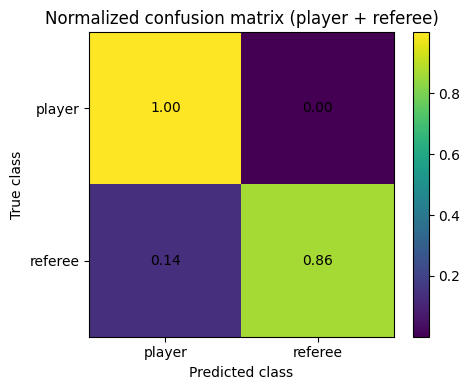

In [25]:
# ----- Matriz de confusión normalizada (player vs referee) -----

labels = [PLAYER_CLASS_ID, REFEREE_CLASS_ID]
label_names = [baseline_model.names[c] for c in labels]

cm = np.zeros((len(labels), len(labels)), dtype=float)
idx_map = {cid: i for i, cid in enumerate(labels)}

for gt, pred in zip(confusion_true, confusion_pred):
    if gt in idx_map and pred in idx_map:
        i = idx_map[gt]
        j = idx_map[pred]
        cm[i, j] += 1.0

row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums > 0)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_norm, interpolation="nearest")
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(label_names)
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Normalized confusion matrix (player + referee)")

# Anotar valores
for i in range(len(labels)):
    for j in range(len(labels)):
        val = cm_norm[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10)

plt.tight_layout()
plt.show()


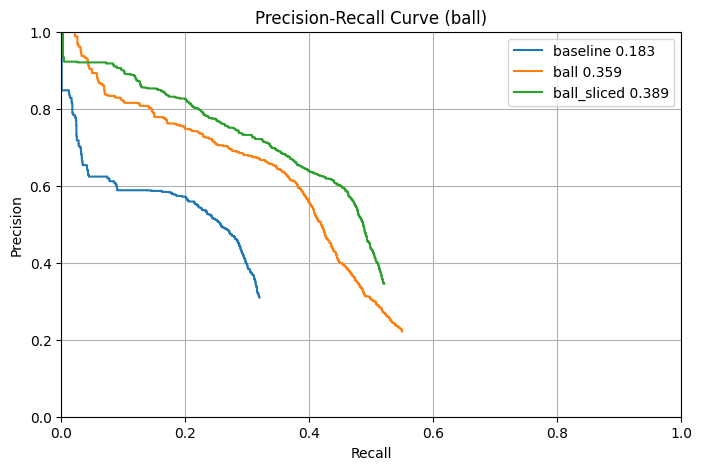

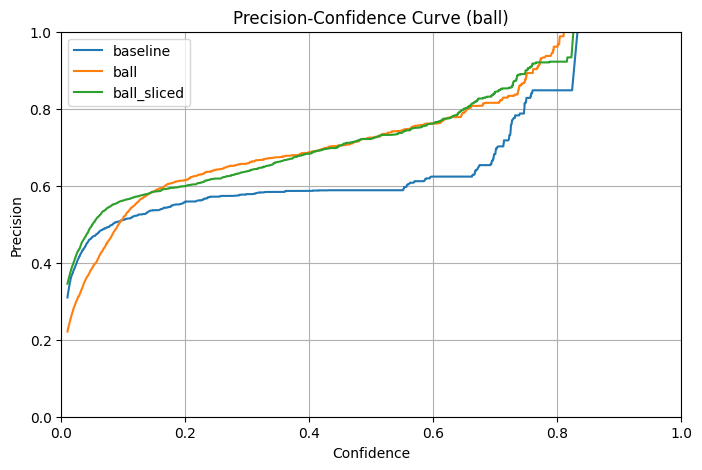

In [26]:
# --------- BALL (baseline vs ball vs ball_sliced) ---------
series_pr_ball = []
series_pc_ball = []

for model_name in ball_models:
    total_gt_ball = ball_stats[model_name]["tp"] + ball_stats[model_name]["fn"]
    rec, prec, conf_sorted = build_pr_curve_monotone(
        ball_pr_data[model_name]["conf"],
        ball_pr_data[model_name]["is_tp"],
        total_gt_ball,
    )
    series_pr_ball.append((rec, prec, model_name))
    series_pc_ball.append((conf_sorted, prec, model_name))

plot_pr_curves(series_pr_ball, "Precision-Recall Curve (ball)")
plot_pc_curves(series_pc_ball, "Precision-Confidence Curve (ball)")
